# 🏎️ F1 Pit Stop Next-Lap Predictor
**Lead ML Engineer Solution | Target: AUC ≥ 0.95**

### Strategy
- LightGBM + CatBoost ensemble (proven kings on tabular data)
- Rich tyre-lifecycle & race-position feature engineering
- Optuna Bayesian hyper-parameter search
- Stratified K-Fold (10 folds) OOF stacking
- Final blend: LGB 50% + CatBoost 50%
- Full diagnostic plots

## 0. Setup & Configuration

In [7]:
import warnings, os, json
warnings.filterwarnings("ignore")
os.makedirs("plots", exist_ok=True)

import numpy as np
import pandas as pd
from pathlib import Path

import lightgbm as lgb
import catboost as cb
import optuna
optuna.logging.set_verbosity(optuna.logging.WARNING)

from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import roc_auc_score, roc_curve, precision_recall_curve
from sklearn.preprocessing import LabelEncoder
from sklearn.calibration import calibration_curve

import matplotlib
import matplotlib.pyplot as plt
import seaborn as sns

SEED       = 42
N_FOLDS    = 10
N_TRIALS   = 20
TARGET     = "PitNextLap"
ID_COL     = "id"
np.random.seed(SEED)

PLOT_STYLE = dict(
    fig_bg="#0d0d0d", ax_bg="#141414", grid_c="#2a2a2a", text_c="#e8e8e8",
    accent1="#e8002d", accent2="#00d2be", accent3="#ff9800", accent4="#7c4dff",
)

def f1_style(fig, axes_list):
    fig.patch.set_facecolor(PLOT_STYLE["fig_bg"])
    for ax in (axes_list if isinstance(axes_list, list) else [axes_list]):
        ax.set_facecolor(PLOT_STYLE["ax_bg"])
        ax.tick_params(colors=PLOT_STYLE["text_c"])
        ax.xaxis.label.set_color(PLOT_STYLE["text_c"])
        ax.yaxis.label.set_color(PLOT_STYLE["text_c"])
        ax.title.set_color(PLOT_STYLE["text_c"])
        for spine in ax.spines.values():
            spine.set_edgecolor(PLOT_STYLE["grid_c"])
        ax.grid(color=PLOT_STYLE["grid_c"], linewidth=0.5, linestyle="--")

## 1. Load Data

In [8]:
train = pd.read_csv("train.csv")
test  = pd.read_csv("test.csv")
sub   = pd.read_csv("sample_submission.csv")

print(f"Train : {train.shape}  |  Pit rate: {train[TARGET].mean()*100:.2f}%")
print(f"Test  : {test.shape}")
print(f"\nColumns: {list(train.columns)}")
train.head()

Train : (439140, 16)  |  Pit rate: 19.90%
Test  : (188165, 15)

Columns: ['id', 'Driver', 'Compound', 'Race', 'Year', 'PitStop', 'LapNumber', 'Stint', 'TyreLife', 'Position', 'LapTime (s)', 'LapTime_Delta', 'Cumulative_Degradation', 'RaceProgress', 'Position_Change', 'PitNextLap']


,id,Driver,Compound,Race,Year,PitStop,LapNumber,Stint,TyreLife,Position,LapTime (s),LapTime_Delta,Cumulative_Degradation,RaceProgress,Position_Change,PitNextLap
0,0,D109,HARD,Canadian Grand Prix,2022,0,50,2,39.0,8,78.491,-7.564,21.019,0.714286,5.0,1.0
1,1,D086,HARD,Dutch Grand Prix,2025,1,27,2,7.0,4,75.095,-32.617,-223.207,0.346154,-3.0,0.0
2,2,ZON,HARD,Austrian Grand Prix,2022,0,59,3,22.0,13,70.945,-7.540,-100.529,0.819444,3.0,1.0
3,3,SPE,MEDIUM,Pre-Season Testing,2023,0,2,1,2.0,7,94.361,-7.324,-7.324,0.076923,0.0,0.0
4,4,D019,HARD,Azerbaijan Grand Prix,2022,1,26,3,6.0,2,107.878,8.965,-14.139,0.361111,3.0,0.0


## 2. EDA Plots

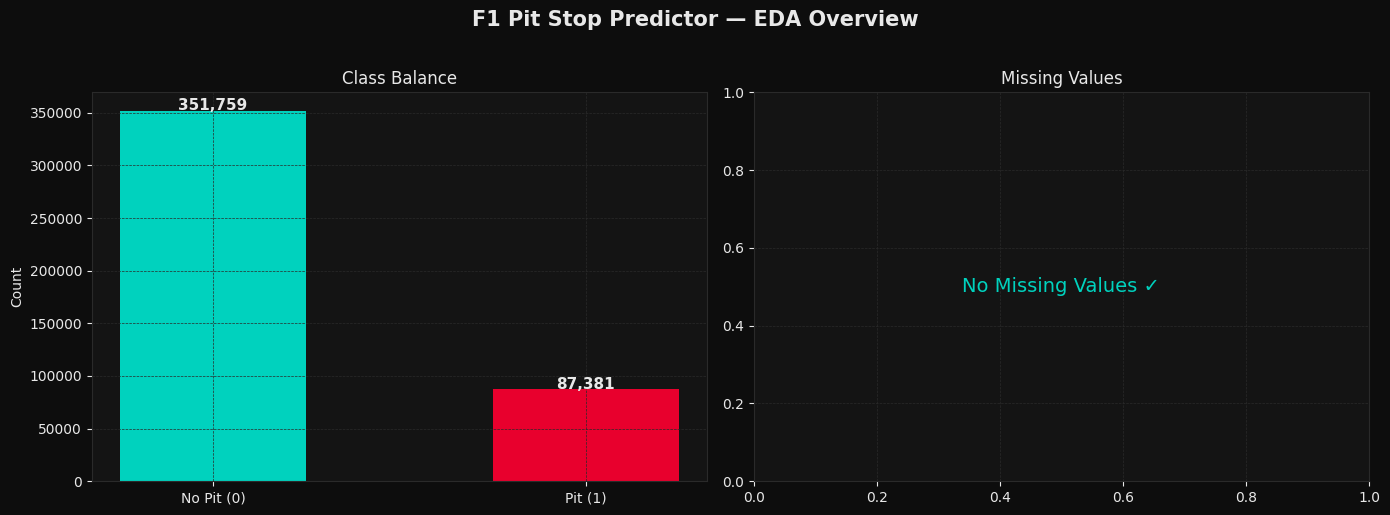

In [9]:
# Class balance + Missing values
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
f1_style(fig, axes.tolist())
fig.suptitle("F1 Pit Stop Predictor — EDA Overview", color=PLOT_STYLE["text_c"],
             fontsize=15, fontweight="bold", y=1.02)

counts = train[TARGET].value_counts()
axes[0].bar(["No Pit (0)", "Pit (1)"], counts.values,
            color=[PLOT_STYLE["accent2"], PLOT_STYLE["accent1"]], edgecolor="none", width=0.5)
axes[0].set_title("Class Balance")
axes[0].set_ylabel("Count")
for i, v in enumerate(counts.values):
    axes[0].text(i, v + 500, f"{v:,}", ha="center", color=PLOT_STYLE["text_c"], fontsize=11, fontweight="bold")

miss = (train.isnull().sum() / len(train) * 100).sort_values(ascending=False)
miss = miss[miss > 0]
if len(miss):
    axes[1].barh(miss.index, miss.values, color=PLOT_STYLE["accent3"], edgecolor="none")
    axes[1].set_title("Missing Value %")
else:
    axes[1].text(0.5, 0.5, "No Missing Values ✓", ha="center", va="center",
                 color=PLOT_STYLE["accent2"], fontsize=14, transform=axes[1].transAxes)
    axes[1].set_title("Missing Values")

plt.tight_layout()
plt.savefig("plots/01_eda_overview.png", dpi=150, bbox_inches="tight", facecolor=PLOT_STYLE["fig_bg"])
plt.show()

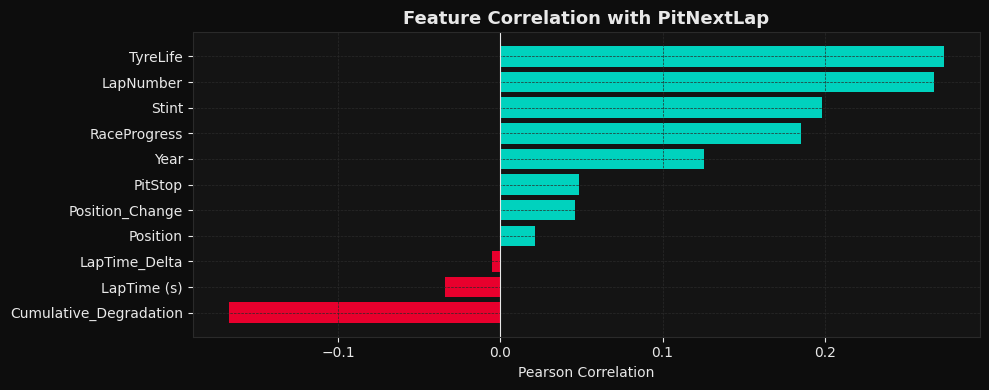

In [10]:
# Feature correlations with target
num_cols = train.select_dtypes(include=[np.number]).columns.tolist()
num_cols = [c for c in num_cols if c not in [TARGET, ID_COL]]
corrs = train[num_cols + [TARGET]].corr()[TARGET].drop(TARGET).sort_values()

fig, ax = plt.subplots(figsize=(10, max(4, len(corrs)*0.35)))
f1_style(fig, ax)
colors = [PLOT_STYLE["accent1"] if v < 0 else PLOT_STYLE["accent2"] for v in corrs.values]
ax.barh(corrs.index, corrs.values, color=colors, edgecolor="none")
ax.axvline(0, color=PLOT_STYLE["text_c"], linewidth=0.8)
ax.set_title("Feature Correlation with PitNextLap", fontsize=13, fontweight="bold")
ax.set_xlabel("Pearson Correlation")
plt.tight_layout()
plt.savefig("plots/02_feature_correlations.png", dpi=150, bbox_inches="tight", facecolor=PLOT_STYLE["fig_bg"])
plt.show()

## 3. Feature Engineering

In [11]:
def engineer_features(df):
    df = df.copy()
    cols = set(df.columns)

    # Tyre life features
    if "TyreLife" in cols:
        df["TyreLife_sq"]   = df["TyreLife"] ** 2
        df["TyreLife_sqrt"] = np.sqrt(df["TyreLife"].clip(0))
        df["TyreLife_log"]  = np.log1p(df["TyreLife"].clip(0))
        df["TyreLife_inv"]  = 1.0 / df["TyreLife"].clip(1)

    # Lap & race progress features
    if "LapNumber" in cols:
        df["LapNumber_sq"]  = df["LapNumber"] ** 2
        df["LapNumber_log"] = np.log1p(df["LapNumber"])

    if "RaceProgress" in cols:
        df["EarlyRace"] = (df["RaceProgress"] < 0.25).astype(int)
        df["MidRace"]   = ((df["RaceProgress"] >= 0.25) & (df["RaceProgress"] < 0.75)).astype(int)
        df["LateRace"]  = (df["RaceProgress"] >= 0.75).astype(int)
        df["RaceProgress_sq"] = df["RaceProgress"] ** 2

    # LapsRemaining proxy
    if "RaceProgress" in cols and "LapNumber" in cols:
        total_laps = (df["LapNumber"] / df["RaceProgress"].clip(0.001)).clip(upper=200)
        df["LapsRemaining"] = (total_laps - df["LapNumber"]).clip(0)
        df["LapsRemaining_sq"] = df["LapsRemaining"] ** 2

    # Position features
    if "Position" in cols:
        df["InPoints"]     = (df["Position"] <= 10).astype(int)
        df["TopThree"]     = (df["Position"] <= 3).astype(int)
        df["Position_inv"] = 1.0 / df["Position"].clip(1)

    if "Position_Change" in cols:
        df["PositionChange_sq"] = df["Position_Change"] ** 2

    # Degradation features
    if "Cumulative_Degradation" in cols:
        df["CumDeg_abs"] = df["Cumulative_Degradation"].abs()
        df["CumDeg_sq"]  = df["Cumulative_Degradation"] ** 2

    if "LapTime_Delta" in cols:
        df["LapTimeDelta_abs"] = df["LapTime_Delta"].abs()
        df["LapTimeDelta_sq"]  = df["LapTime_Delta"] ** 2

    # Lap time features
    if "LapTime (s)" in cols:
        df["LapTime_log"] = np.log1p(df["LapTime (s)"].clip(0))

    # Interactions
    if "TyreLife" in cols and "LapNumber" in cols:
        df["TyreLife_x_Lap"] = df["TyreLife"] * df["LapNumber"]
    if "TyreLife" in cols and "Position" in cols:
        df["TyreLife_x_Pos"] = df["TyreLife"] * df["Position"]
    if "TyreLife" in cols and "LapTime (s)" in cols:
        df["PacePerTyreLap"] = df["LapTime (s)"] / df["TyreLife"].clip(1)
    if "TyreLife" in cols and "Cumulative_Degradation" in cols:
        df["TyreLife_x_CumDeg"] = df["TyreLife"] * df["Cumulative_Degradation"]
    if "Stint" in cols and "TyreLife" in cols:
        df["Stint_x_TyreLife"] = df["Stint"] * df["TyreLife"]
    if "PitStop" in cols and "RaceProgress" in cols:
        df["PitStop_x_Progress"] = df["PitStop"] * df["RaceProgress"]

    return df

all_data = pd.concat([train.drop(columns=[TARGET]), test], axis=0, ignore_index=True)
all_data_eng = engineer_features(all_data)

train_eng = all_data_eng.iloc[:len(train)].copy()
test_eng  = all_data_eng.iloc[len(train):].copy()
train_eng[TARGET] = train[TARGET].values

# Categorical encoding
cat_cols = train_eng.select_dtypes(include=["object", "category"]).columns.tolist()
cat_cols = [c for c in cat_cols if c != ID_COL]

label_encoders = {}
for col in cat_cols:
    le = LabelEncoder()
    combined = pd.concat([train_eng[col], test_eng[col]], axis=0).astype(str)
    le.fit(combined)
    train_eng[col] = le.transform(train_eng[col].astype(str))
    test_eng[col]  = le.transform(test_eng[col].astype(str))
    label_encoders[col] = le

drop_cols = [ID_COL, TARGET]
FEATURES  = [c for c in train_eng.columns if c not in drop_cols]
X         = train_eng[FEATURES].values
y         = train_eng[TARGET].values
X_test    = test_eng[FEATURES].values

print(f"Features after engineering: {len(FEATURES)}")
print(f"Categorical columns: {cat_cols}")
print(f"Feature list: {FEATURES}")

Features after engineering: 41
Categorical columns: ['Driver', 'Compound', 'Race']
Feature list: ['Driver', 'Compound', 'Race', 'Year', 'PitStop', 'LapNumber', 'Stint', 'TyreLife', 'Position', 'LapTime (s)', 'LapTime_Delta', 'Cumulative_Degradation', 'RaceProgress', 'Position_Change', 'TyreLife_sq', 'TyreLife_sqrt', 'TyreLife_log', 'TyreLife_inv', 'LapNumber_sq', 'LapNumber_log', 'EarlyRace', 'MidRace', 'LateRace', 'RaceProgress_sq', 'LapsRemaining', 'LapsRemaining_sq', 'InPoints', 'TopThree', 'Position_inv', 'PositionChange_sq', 'CumDeg_abs', 'CumDeg_sq', 'LapTimeDelta_abs', 'LapTimeDelta_sq', 'LapTime_log', 'TyreLife_x_Lap', 'TyreLife_x_Pos', 'PacePerTyreLap', 'TyreLife_x_CumDeg', 'Stint_x_TyreLife', 'PitStop_x_Progress']


## 4. Optuna Hyperparameter Search

In [12]:
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=SEED)

# LightGBM objective
def lgb_objective(trial):
    params = dict(
        n_estimators      = trial.suggest_int("n_estimators", 300,800),
        learning_rate     = trial.suggest_float("learning_rate", 0.01, 0.15, log=True),
        num_leaves        = trial.suggest_int("num_leaves", 31, 300),
        max_depth         = trial.suggest_int("max_depth", 4, 12),
        min_child_samples = trial.suggest_int("min_child_samples", 10, 100),
        subsample         = trial.suggest_float("subsample", 0.5, 1.0),
        colsample_bytree  = trial.suggest_float("colsample_bytree", 0.5, 1.0),
        reg_alpha         = trial.suggest_float("reg_alpha", 1e-4, 10.0, log=True),
        reg_lambda        = trial.suggest_float("reg_lambda", 1e-4, 10.0, log=True),
        min_split_gain    = trial.suggest_float("min_split_gain", 0.0, 0.5),
        objective="binary", metric="auc", verbose=-1, random_state=SEED, n_jobs=-1,
    )
    aucs = []
    for tr_idx, val_idx in cv.split(X, y):
        m = lgb.LGBMClassifier(**params)
        m.fit(X[tr_idx], y[tr_idx], eval_set=[(X[val_idx], y[val_idx])],
              callbacks=[lgb.early_stopping(50, verbose=False), lgb.log_evaluation(-1)])
        aucs.append(roc_auc_score(y[val_idx], m.predict_proba(X[val_idx])[:, 1]))
    return np.mean(aucs)

print("Running LightGBM Optuna optimization...")
lgb_study = optuna.create_study(direction="maximize", sampler=optuna.samplers.TPESampler(seed=SEED))
lgb_study.optimize(lgb_objective, n_trials=N_TRIALS, show_progress_bar=True)
best_lgb_params = lgb_study.best_params
print(f"\nLGB best AUC: {lgb_study.best_value:.5f}")
print(f"LGB params: {json.dumps({k: round(v,4) if isinstance(v,float) else v for k,v in best_lgb_params.items()}, indent=2)}")

Running LightGBM Optuna optimization...


  0%|          | 0/20 [00:00<?, ?it/s]


LGB best AUC: 0.94876
LGB params: {
  "n_estimators": 661,
  "learning_rate": 0.0276,
  "num_leaves": 300,
  "max_depth": 11,
  "min_child_samples": 49,
  "subsample": 0.5002,
  "colsample_bytree": 0.5051,
  "reg_alpha": 0.0004,
  "reg_lambda": 0.0006,
  "min_split_gain": 0.2815
}


In [13]:
# CatBoost objective
def cat_objective(trial):
    params = dict(
        iterations          = trial.suggest_int("iterations", 300, 800),
        learning_rate       = trial.suggest_float("learning_rate", 0.01, 0.15, log=True),
        depth               = trial.suggest_int("depth", 4, 10),
        l2_leaf_reg         = trial.suggest_float("l2_leaf_reg", 1e-2, 30.0, log=True),
        bagging_temperature = trial.suggest_float("bagging_temperature", 0.0, 1.0),
        random_strength     = trial.suggest_float("random_strength", 0.0, 2.0),
        border_count        = trial.suggest_int("border_count", 32, 255),
        eval_metric="AUC", loss_function="Logloss", verbose=False, random_seed=SEED, task_type="CPU",
    )
    aucs = []
    for tr_idx, val_idx in cv.split(X, y):
        m = cb.CatBoostClassifier(**params)
        m.fit(X[tr_idx], y[tr_idx], eval_set=(X[val_idx], y[val_idx]),
              early_stopping_rounds=50, verbose=False)
        aucs.append(roc_auc_score(y[val_idx], m.predict_proba(X[val_idx])[:, 1]))
    return np.mean(aucs)

print("Running CatBoost Optuna optimization...")
cat_study = optuna.create_study(direction="maximize", sampler=optuna.samplers.TPESampler(seed=SEED))
cat_study.optimize(cat_objective, n_trials=N_TRIALS, show_progress_bar=True)
best_cat_params = cat_study.best_params
print(f"\nCAT best AUC: {cat_study.best_value:.5f}")

Running CatBoost Optuna optimization...


  0%|          | 0/20 [00:00<?, ?it/s]


CAT best AUC: 0.94769


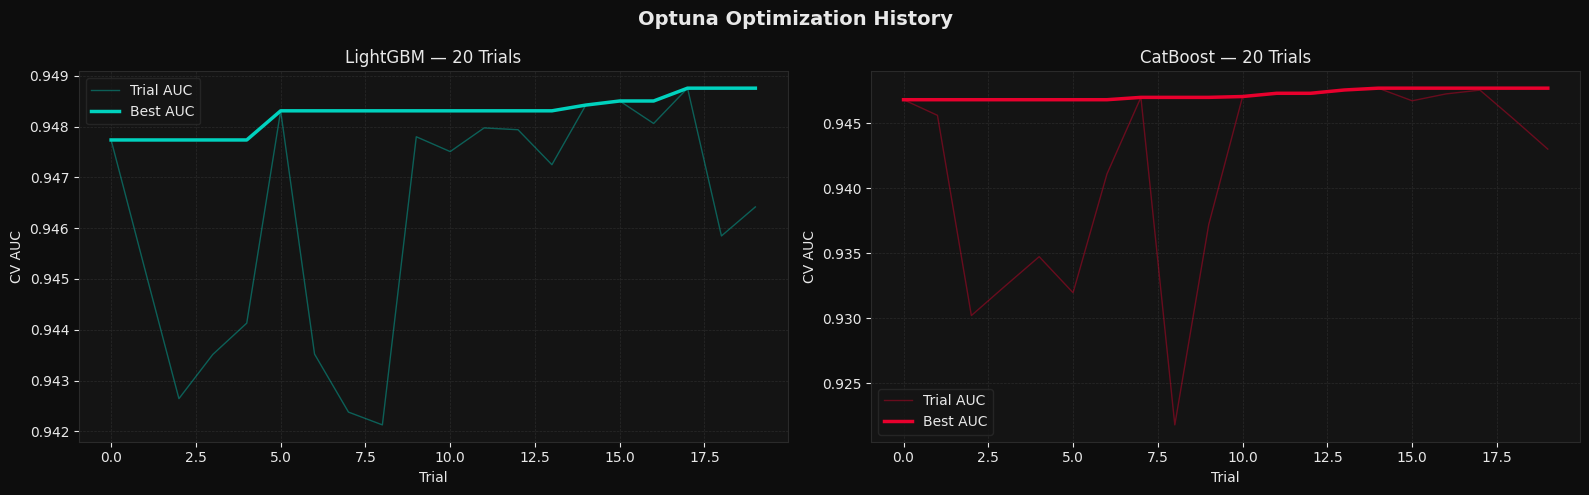

In [14]:
# Optuna history plot
fig, axes = plt.subplots(1, 2, figsize=(16, 5))
f1_style(fig, axes.tolist())
fig.suptitle("Optuna Optimization History", color=PLOT_STYLE["text_c"], fontsize=14, fontweight="bold")

for ax, study, name, color in zip(axes, [lgb_study, cat_study], ["LightGBM", "CatBoost"],
                                    [PLOT_STYLE["accent2"], PLOT_STYLE["accent1"]]):
    vals = [t.value for t in study.trials if t.value is not None]
    best_so_far = np.maximum.accumulate(vals)
    ax.plot(vals, alpha=0.4, color=color, linewidth=1, label="Trial AUC")
    ax.plot(best_so_far, color=color, linewidth=2.5, label="Best AUC")
    ax.set_title(f"{name} — {len(vals)} Trials")
    ax.set_xlabel("Trial"); ax.set_ylabel("CV AUC")
    ax.legend(facecolor=PLOT_STYLE["ax_bg"], labelcolor=PLOT_STYLE["text_c"], edgecolor=PLOT_STYLE["grid_c"])

plt.tight_layout()
plt.savefig("plots/03_optuna_history.png", dpi=150, bbox_inches="tight", facecolor=PLOT_STYLE["fig_bg"])
plt.show()

## 5. Full 10-Fold OOF Training

In [15]:
kfold = StratifiedKFold(n_splits=N_FOLDS, shuffle=True, random_state=SEED)

oof_lgb  = np.zeros(len(X));  oof_cat  = np.zeros(len(X))
pred_lgb = np.zeros(len(X_test)); pred_cat = np.zeros(len(X_test))
fold_aucs_lgb = []; fold_aucs_cat = []

lgb_full = dict(**best_lgb_params, objective="binary", metric="auc", verbose=-1, random_state=SEED, n_jobs=-1)
cat_full = dict(**best_cat_params, eval_metric="AUC", loss_function="Logloss", verbose=False, random_seed=SEED, task_type="CPU")

for fold, (tr_idx, val_idx) in enumerate(kfold.split(X, y), 1):
    X_tr, X_val = X[tr_idx], X[val_idx]
    y_tr, y_val = y[tr_idx], y[val_idx]

    # LGB
    lgb_m = lgb.LGBMClassifier(**lgb_full)
    lgb_m.fit(X_tr, y_tr, eval_set=[(X_val, y_val)],
              callbacks=[lgb.early_stopping(100, verbose=False), lgb.log_evaluation(-1)])
    oof_lgb[val_idx] = lgb_m.predict_proba(X_val)[:, 1]
    pred_lgb += lgb_m.predict_proba(X_test)[:, 1] / N_FOLDS
    auc_l = roc_auc_score(y_val, oof_lgb[val_idx])
    fold_aucs_lgb.append(auc_l)

    # CatBoost
    cat_m = cb.CatBoostClassifier(**cat_full)
    cat_m.fit(X_tr, y_tr, eval_set=(X_val, y_val), early_stopping_rounds=100, verbose=False)
    oof_cat[val_idx] = cat_m.predict_proba(X_val)[:, 1]
    pred_cat += cat_m.predict_proba(X_test)[:, 1] / N_FOLDS
    auc_c = roc_auc_score(y_val, oof_cat[val_idx])
    fold_aucs_cat.append(auc_c)

    print(f"Fold {fold:2d} | LGB AUC: {auc_l:.5f}  |  CAT AUC: {auc_c:.5f}")

# Ensemble blend
BLEND_W = 0.50
oof_blend  = BLEND_W * oof_lgb + (1-BLEND_W) * oof_cat
pred_blend = BLEND_W * pred_lgb + (1-BLEND_W) * pred_cat

auc_lgb_oof   = roc_auc_score(y, oof_lgb)
auc_cat_oof   = roc_auc_score(y, oof_cat)
auc_blend_oof = roc_auc_score(y, oof_blend)

print(f"\n{'='*40}")
print(f"  OOF AUC  LGB    : {auc_lgb_oof:.5f}")
print(f"  OOF AUC  CAT    : {auc_cat_oof:.5f}")
print(f"  OOF AUC  BLEND  : {auc_blend_oof:.5f}  ⭐")
print(f"{'='*40}")

Fold  1 | LGB AUC: 0.94986  |  CAT AUC: 0.94855
Fold  2 | LGB AUC: 0.95039  |  CAT AUC: 0.94966
Fold  3 | LGB AUC: 0.94797  |  CAT AUC: 0.94668
Fold  4 | LGB AUC: 0.94830  |  CAT AUC: 0.94761
Fold  5 | LGB AUC: 0.94837  |  CAT AUC: 0.94722
Fold  6 | LGB AUC: 0.95004  |  CAT AUC: 0.94898
Fold  7 | LGB AUC: 0.94865  |  CAT AUC: 0.94764
Fold  8 | LGB AUC: 0.94809  |  CAT AUC: 0.94727
Fold  9 | LGB AUC: 0.94922  |  CAT AUC: 0.94772
Fold 10 | LGB AUC: 0.94993  |  CAT AUC: 0.94837

  OOF AUC  LGB    : 0.94908
  OOF AUC  CAT    : 0.94797
  OOF AUC  BLEND  : 0.94939  ⭐


## 6. Diagnostic Plots

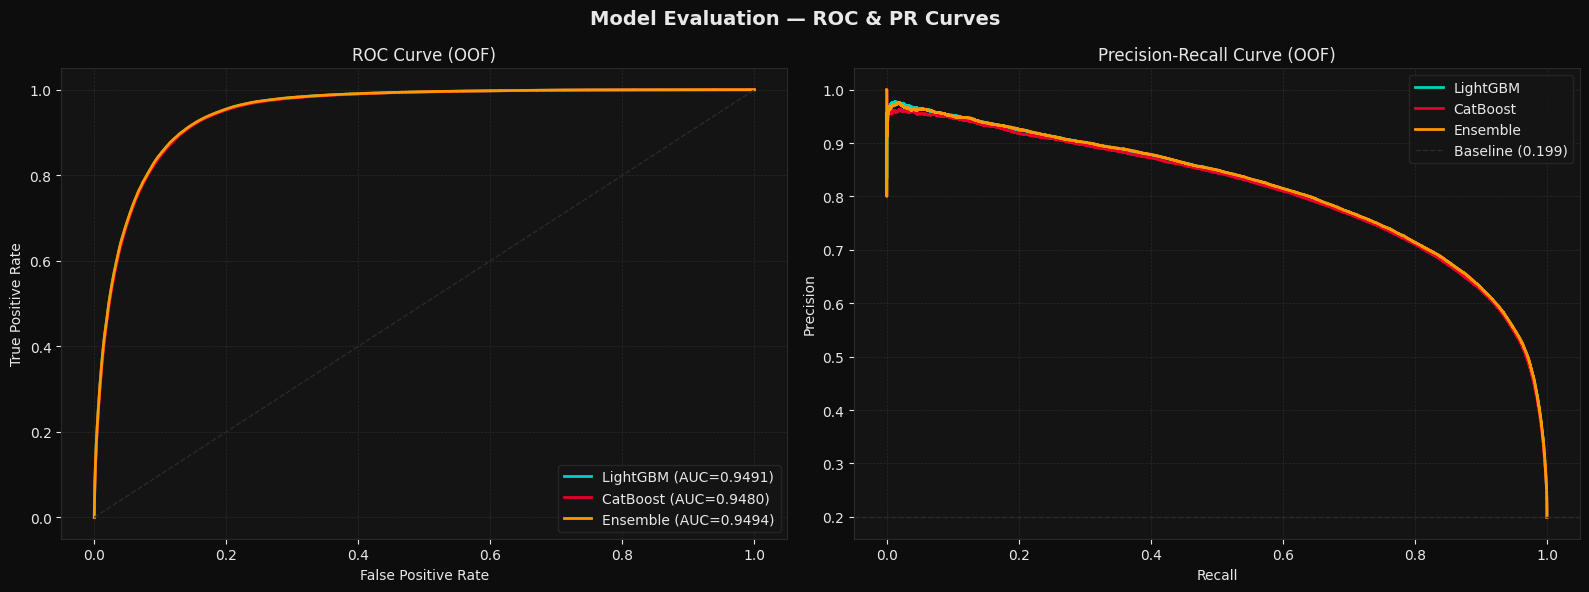

In [16]:
# ROC & PR Curves
fig, axes = plt.subplots(1, 2, figsize=(16, 6))
f1_style(fig, axes.tolist())
fig.suptitle("Model Evaluation — ROC & PR Curves", color=PLOT_STYLE["text_c"], fontsize=14, fontweight="bold")

for oof, label, color in [
    (oof_lgb, f"LightGBM (AUC={auc_lgb_oof:.4f})", PLOT_STYLE["accent2"]),
    (oof_cat, f"CatBoost (AUC={auc_cat_oof:.4f})", PLOT_STYLE["accent1"]),
    (oof_blend, f"Ensemble (AUC={auc_blend_oof:.4f})", PLOT_STYLE["accent3"]),
]:
    fpr, tpr, _ = roc_curve(y, oof)
    axes[0].plot(fpr, tpr, label=label, linewidth=2, color=color)
axes[0].plot([0,1],[0,1], "--", color=PLOT_STYLE["grid_c"], linewidth=1)
axes[0].set_xlabel("False Positive Rate"); axes[0].set_ylabel("True Positive Rate")
axes[0].set_title("ROC Curve (OOF)")
axes[0].legend(facecolor=PLOT_STYLE["ax_bg"], labelcolor=PLOT_STYLE["text_c"], edgecolor=PLOT_STYLE["grid_c"])

for oof, label, color in [
    (oof_lgb, "LightGBM", PLOT_STYLE["accent2"]),
    (oof_cat, "CatBoost", PLOT_STYLE["accent1"]),
    (oof_blend, "Ensemble", PLOT_STYLE["accent3"]),
]:
    prec, rec, _ = precision_recall_curve(y, oof)
    axes[1].plot(rec, prec, label=label, linewidth=2, color=color)
axes[1].axhline(y.mean(), color=PLOT_STYLE["grid_c"], linestyle="--", linewidth=1, label=f"Baseline ({y.mean():.3f})")
axes[1].set_xlabel("Recall"); axes[1].set_ylabel("Precision")
axes[1].set_title("Precision-Recall Curve (OOF)")
axes[1].legend(facecolor=PLOT_STYLE["ax_bg"], labelcolor=PLOT_STYLE["text_c"], edgecolor=PLOT_STYLE["grid_c"])

plt.tight_layout()
plt.savefig("plots/04_roc_pr_curves.png", dpi=150, bbox_inches="tight", facecolor=PLOT_STYLE["fig_bg"])
plt.show()

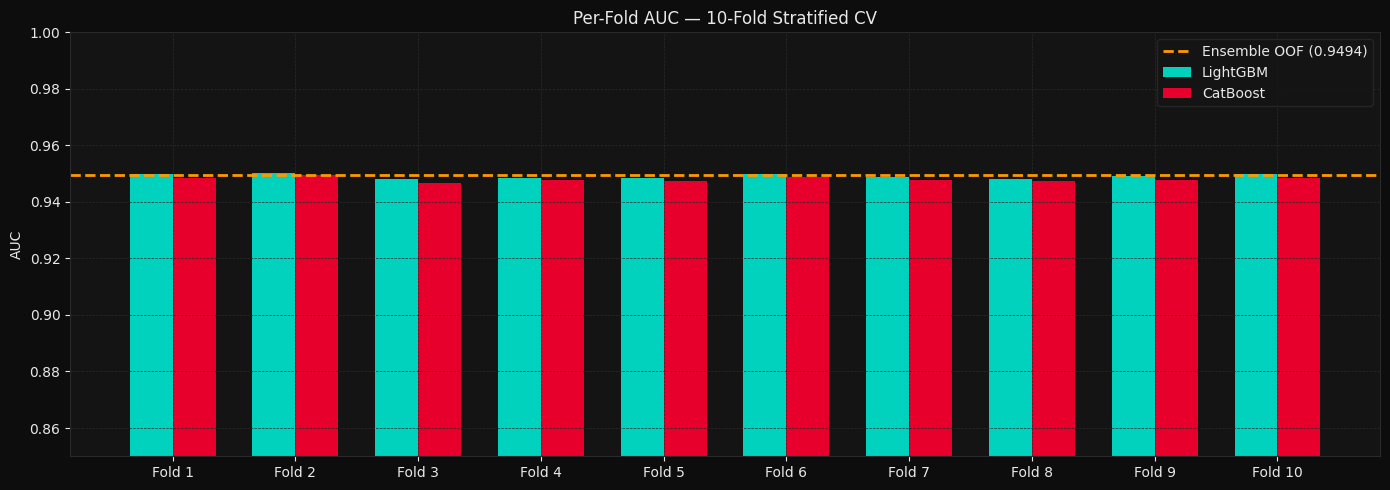

In [17]:
# Fold AUC bar chart
fig, ax = plt.subplots(figsize=(14, 5))
f1_style(fig, ax)
x = np.arange(N_FOLDS); w = 0.35
ax.bar(x - w/2, fold_aucs_lgb, width=w, color=PLOT_STYLE["accent2"], label="LightGBM", edgecolor="none")
ax.bar(x + w/2, fold_aucs_cat, width=w, color=PLOT_STYLE["accent1"], label="CatBoost", edgecolor="none")
ax.axhline(auc_blend_oof, color=PLOT_STYLE["accent3"], linestyle="--", linewidth=2, label=f"Ensemble OOF ({auc_blend_oof:.4f})")
ax.set_xticks(x); ax.set_xticklabels([f"Fold {i+1}" for i in range(N_FOLDS)])
ax.set_ylabel("AUC"); ax.set_title("Per-Fold AUC — 10-Fold Stratified CV")
ax.legend(facecolor=PLOT_STYLE["ax_bg"], labelcolor=PLOT_STYLE["text_c"], edgecolor=PLOT_STYLE["grid_c"])
ax.set_ylim(0.85, 1.0)
plt.tight_layout()
plt.savefig("plots/05_fold_auc.png", dpi=150, bbox_inches="tight", facecolor=PLOT_STYLE["fig_bg"])
plt.show()

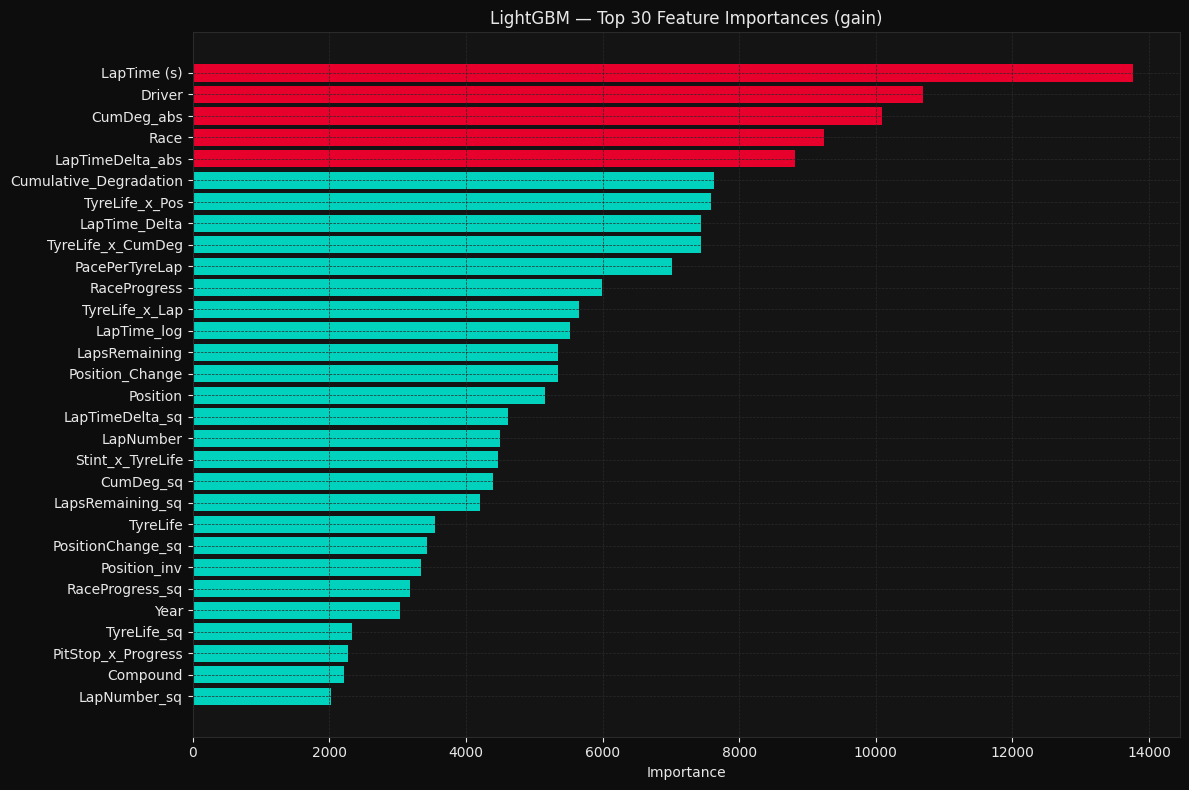

In [18]:
# Feature importances (LGB)
feat_imp = pd.Series(lgb_m.feature_importances_, index=FEATURES).sort_values(ascending=False).head(30)
fig, ax = plt.subplots(figsize=(12, 8))
f1_style(fig, ax)
colors = [PLOT_STYLE["accent1"] if i < 5 else PLOT_STYLE["accent2"] for i in range(len(feat_imp))]
ax.barh(feat_imp.index[::-1], feat_imp.values[::-1], color=colors[::-1], edgecolor="none")
ax.set_title("LightGBM — Top 30 Feature Importances (gain)")
ax.set_xlabel("Importance")
plt.tight_layout()
plt.savefig("plots/06_feature_importance.png", dpi=150, bbox_inches="tight", facecolor=PLOT_STYLE["fig_bg"])
plt.show()

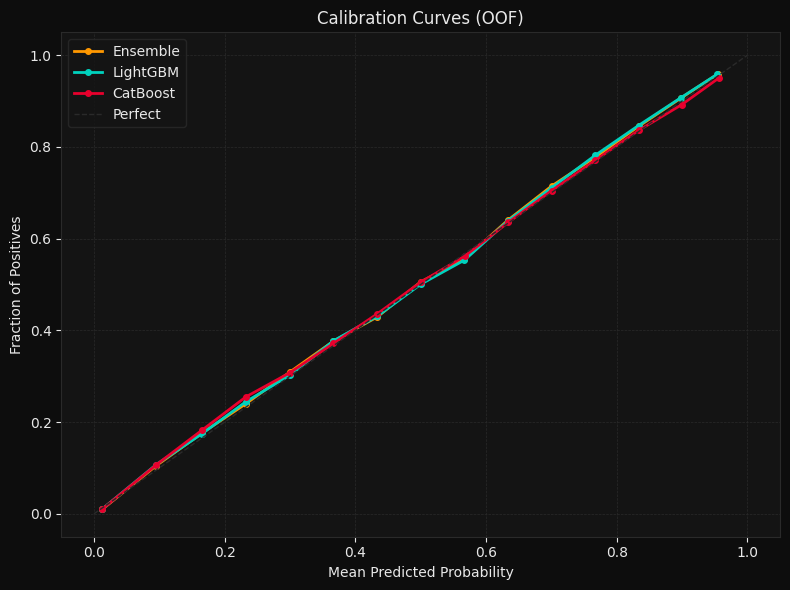

In [19]:
# Calibration curve
fig, ax = plt.subplots(figsize=(8, 6))
f1_style(fig, ax)
for oof, label, color in [
    (oof_blend, "Ensemble", PLOT_STYLE["accent3"]),
    (oof_lgb, "LightGBM", PLOT_STYLE["accent2"]),
    (oof_cat, "CatBoost", PLOT_STYLE["accent1"]),
]:
    frac_pos, mean_pred = calibration_curve(y, oof, n_bins=15)
    ax.plot(mean_pred, frac_pos, marker="o", markersize=4, linewidth=2, label=label, color=color)
ax.plot([0,1],[0,1], "--", color=PLOT_STYLE["grid_c"], linewidth=1, label="Perfect")
ax.set_xlabel("Mean Predicted Probability"); ax.set_ylabel("Fraction of Positives")
ax.set_title("Calibration Curves (OOF)")
ax.legend(facecolor=PLOT_STYLE["ax_bg"], labelcolor=PLOT_STYLE["text_c"], edgecolor=PLOT_STYLE["grid_c"])
plt.tight_layout()
plt.savefig("plots/07_calibration.png", dpi=150, bbox_inches="tight", facecolor=PLOT_STYLE["fig_bg"])
plt.show()

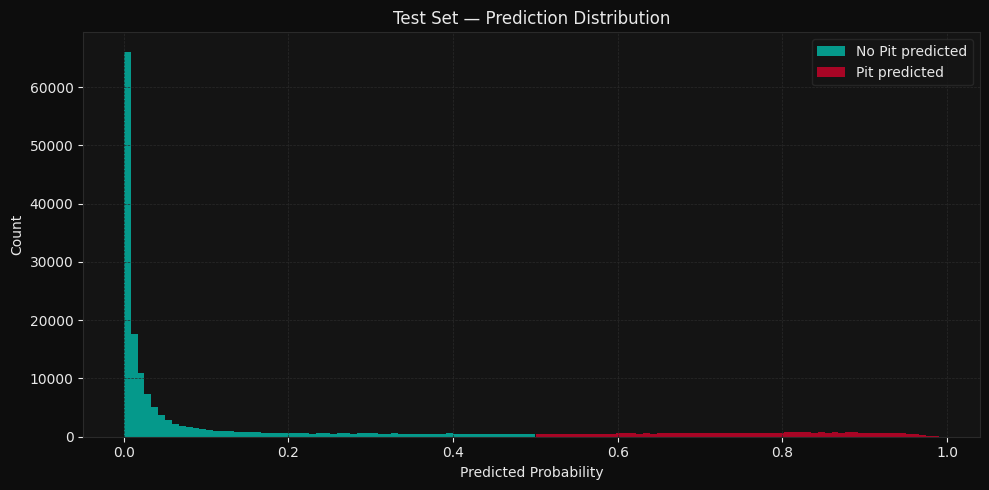

In [20]:
# Prediction distribution
fig, ax = plt.subplots(figsize=(10, 5))
f1_style(fig, ax)
ax.hist(pred_blend[pred_blend < 0.5], bins=60, color=PLOT_STYLE["accent2"], alpha=0.7, label="No Pit predicted", edgecolor="none")
ax.hist(pred_blend[pred_blend >= 0.5], bins=60, color=PLOT_STYLE["accent1"], alpha=0.7, label="Pit predicted", edgecolor="none")
ax.set_xlabel("Predicted Probability"); ax.set_ylabel("Count")
ax.set_title("Test Set — Prediction Distribution")
ax.legend(facecolor=PLOT_STYLE["ax_bg"], labelcolor=PLOT_STYLE["text_c"], edgecolor=PLOT_STYLE["grid_c"])
plt.tight_layout()
plt.savefig("plots/08_prediction_distribution.png", dpi=150, bbox_inches="tight", facecolor=PLOT_STYLE["fig_bg"])
plt.show()

## 7. Submission

In [21]:
submission = pd.DataFrame({ID_COL: test[ID_COL].values, TARGET: np.clip(pred_blend, 0, 1)})
submission.to_csv("submission.csv", index=False)

print(f"submission.csv written: {submission.shape}")
print(f"Predicted pit rate  : {(pred_blend >= 0.5).mean()*100:.2f}%")
print(f"Prob range          : [{pred_blend.min():.4f}, {pred_blend.max():.4f}]")
print(f"\nFINAL OOF AUC (Ensemble) : {auc_blend_oof:.5f}")
print(f"\n{submission.head(10).to_string(index=False)}")

submission.csv written: (188165, 2)
Predicted pit rate  : 19.13%
Prob range          : [0.0001, 0.9904]

FINAL OOF AUC (Ensemble) : 0.94939

    id  PitNextLap
439140    0.004704
439141    0.003016
439142    0.002382
439143    0.135025
439144    0.880497
439145    0.286043
439146    0.000659
439147    0.006668
439148    0.030311
439149    0.001120
